# Array Configuration Generation
This notebook generates and visualizes various antenna array configurations for FASR using `fasr_solar_simul` (fss).

In [2]:
import fasr_solar_simul as fss
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c
import os

# Speed of light in m/s
C_LIGHT = c
import matplotlib
%matplotlib inline

## Set Site Information

In [3]:
# set reference longtitude and latitude
dsa_longitude = -114.425164
dsa_latitude = 39.54780
dsa_altitude = 1736.125

## 3-armed Log Spiral Configurations

Number of turns 1.497372046505208
Minimum baseline length: 17.4 m
Maximum baseline length: 4623.4 m
'generate_log_spiral_antenna_positions' completed at 2026-02-02 12:23:30; runtime: 0.00 seconds
fig saved to fig-fasr_Log_Spiral-72-n_arms=3-antennas_per_arm=24-k=0.43-r0=35.0-r_max=2000.jpg
Set 1: Beam (Natural) FWHM Major: 22.42 arcsec, Minor: 21.85"
Set 1: Beam (Uniform) FWHM Major: 4.58 arcsec, Minor: 4.50"
Set 1: Sidelobe RMS (Natural): 0.8%
Set 1: Sidelobe RMS (Uniform): 1.6%
'plot_all_panels' completed at 2026-02-02 12:23:31; runtime: 1.33 seconds


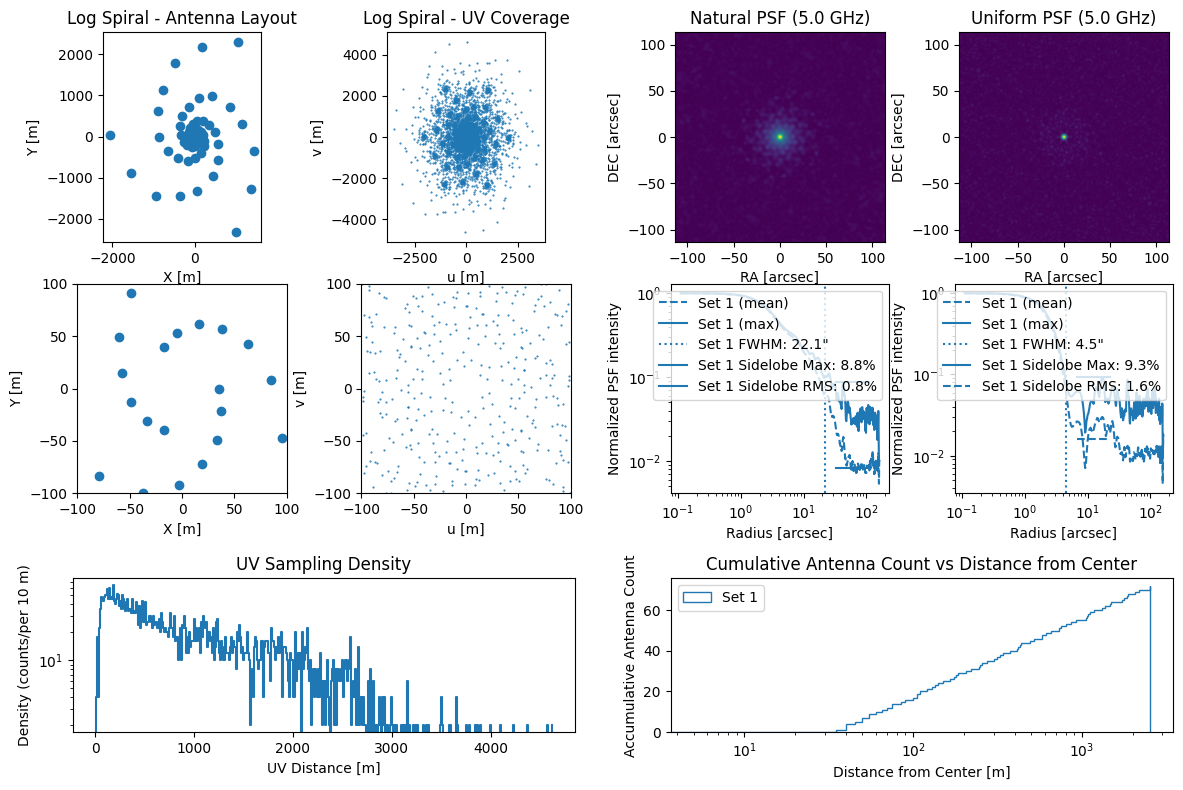

In [4]:
from importlib import reload
reload(fss)
# 72-element spiral with an optimized winding parameter k (corresponding to 1.5 turns), 
#     inner radius of 35 m, and outer radius of 2000 m

# Define log-spiral parameters
array_config = {"n_arms": 3, "antennas_per_arm": 24, "k": 0.43, "r0": 35, "r_max": 2000,
                "latitude": dsa_latitude, "clockwise":True}


positions_logspiral = fss.generate_log_spiral_antenna_positions(**array_config)

figname = (
    f"fig-fasr_Log_Spiral-{len(positions_logspiral)}-"
    f"n_arms={array_config['n_arms']}-antennas_per_arm={array_config['antennas_per_arm']}-"
    f"k={array_config['k']:.2f}-"
    f"r0={array_config['r0']:.1f}-r_max={array_config['r_max']:.0f}.jpg")
print(f'fig saved to {figname}')
figsubfolder = figname.rstrip('.jpg')
formatted_params = [
    rf"$n_{{\rm arms}}={array_config['n_arms']}$",
    rf"$\mbox{{antennas per arm}}={array_config['antennas_per_arm']}$",
    rf"$k={array_config['k']:.2f}$",
    rf"$r_0={array_config['r0']:.1f}\,\mbox{{m}}$",
    rf"$r_{{\rm max}}={array_config['r_max']:.0f}\,\mbox{{m}}$"
]

# Create a full string that also includes the spiral equation.
array_config_str = (
    rf"$n_{{arms}}={array_config['n_arms']}, "
    rf"n_{{perarm}}={array_config['antennas_per_arm']}, "
    rf"k={array_config['k']:.2f}, "
    rf"r_0={array_config['r0']:.1f}\,m, r_{{max}}={array_config['r_max']:.0f}\,m$"
)
fss.plot_all_panels(positions_logspiral, "Log Spiral", frequency=5, figname=figname, plot_psf_fit=False)
# fig = plt.gcf()
# ax = fig.axes[0]
# ax.set_xlim(-10,10)
# ax.set_ylim(-10,10)

## Generate a hybrid array with a 72-element spiral and a dense random core

Generating spiral with 3 arms, 24 antennas per arm
Total spiral antennas: 72
Adjusted core antennas to: 48
Generated 48 core antennas
Minimum baseline length: 1.6 m
Maximum baseline length: 4494.8 m
fig saved to fig-fasr-a-hybrid-120-n_core=48-sigma_g=15.2-n_turns=1.5-r_start=35.0-r_max=2000.jpg
Set 1: Beam (Natural) FWHM Major: 47.86 arcsec, Minor: 47.07"
Set 1: Beam (Uniform) FWHM Major: 4.68 arcsec, Minor: 4.81"
Set 1: Sidelobe RMS (Natural): 3.3%
Set 1: Sidelobe RMS (Uniform): 1.5%
'plot_all_panels' completed at 2026-02-02 12:23:33; runtime: 1.06 seconds


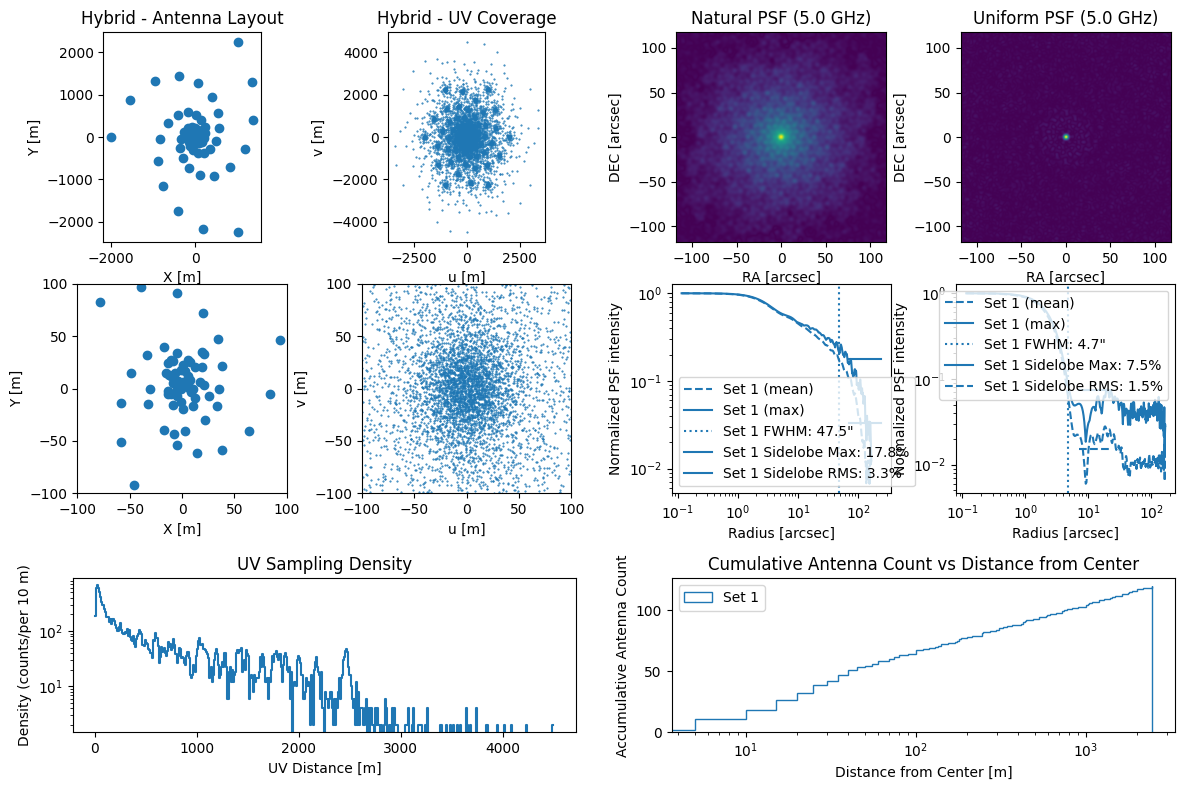

In [5]:
# Define hybrid parameters
reload(fss)
array_config = {"n_antennas": 120, "min_dist": 1.5, "n_core":48,
                                      "r_start": 35.0, "r_max": 2000., "n_turns": 1.5, "rotation_offset": 0., "sigma_g": 15.2,
                                      "latitude": 39.5846}


positions_hybrid = fss.generate_hybrid_rand_spiral_array(**array_config)

figname = (
    f"fig-fasr-a-hybrid-{len(positions_hybrid)}-"
    f"n_core={array_config['n_core']}-sigma_g={array_config['sigma_g']:.1f}-"
    f"n_turns={array_config['n_turns']:.1f}-"
    f"r_start={array_config['r_start']:.1f}-r_max={array_config['r_max']:.0f}.jpg")
print(f'fig saved to {figname}')
fss.plot_all_panels(positions_hybrid, "Hybrid", frequency=5, figname=figname, plot_psf_fit=False)

## Save the configuration for FASR-A hybrid configuration

In [6]:
config_file = f"fasr-a_random_spiral_hybrid_{len(positions_hybrid)}.cfg"
if os.path.exists(config_file):
    print(f'Requested configuration file {config_file} already exists. Adding version number to it.')
    n = 0
    while n < 1000:
        config_filename = config_file.replace('.cfg', f'.00{n+1}.cfg')
        if os.path.exists(config_filename):
            n +=1
        else:
            break
print(f'writing configuration file {config_filename}')
fss.write_casa_antenna_list(config_filename, positions_hybrid, 
                            cofa_lon=dsa_longitude, cofa_lat=dsa_latitude, cofa_alt=dsa_altitude, diam=1.5)

Requested configuration file fasr-a_random_spiral_hybrid_120.cfg already exists. Adding version number to it.
writing configuration file fasr-a_random_spiral_hybrid_120.003.cfg
Wrote fasr-a_random_spiral_hybrid_120.003.cfg


Set 1: Beam (Natural) FWHM Major: 37.50 arcsec, Minor: 37.23"
Set 1: Beam (Uniform) FWHM Major: 3.99 arcsec, Minor: 3.98"
Set 1: Sidelobe RMS (Natural): 1.6%
Set 1: Sidelobe RMS (Uniform): 0.9%
Set 2: Beam (Natural) FWHM Major: 47.62 arcsec, Minor: 47.04"
Set 2: Beam (Uniform) FWHM Major: 4.68 arcsec, Minor: 4.81"
Set 2: Sidelobe RMS (Natural): 3.3%
Set 2: Sidelobe RMS (Uniform): 1.5%
'plot_all_panels' completed at 2026-02-02 12:23:35; runtime: 1.52 seconds


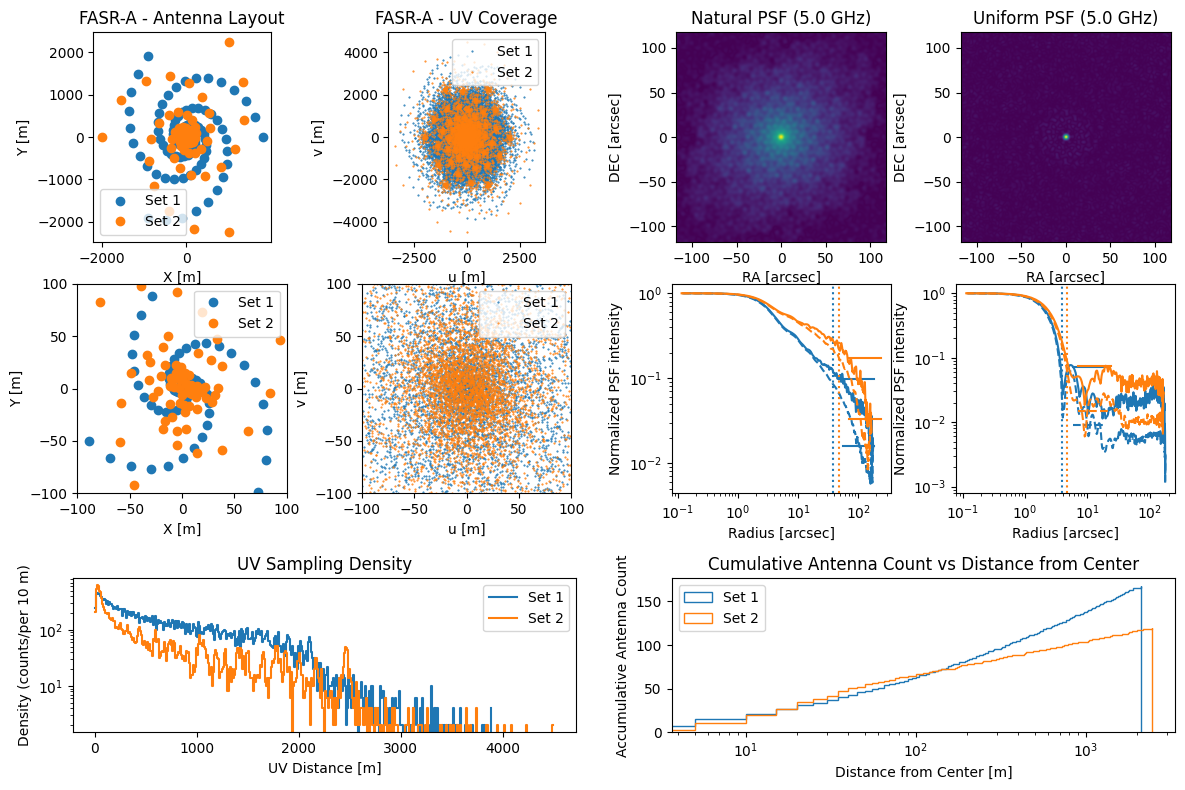

In [7]:
import importlib
importlib.reload(fss)
positions_sy, _ = fss.read_casa_antenna_list('fasr_Log_Spiral-168.cfg')
positions_hybrid, _ = fss.read_casa_antenna_list('fasr-a_random_spiral_hybrid_120.cfg')
fss.plot_all_panels([positions_sy, positions_hybrid], "FASR-A", plot_psf_fit=False, no_psf_legend=True)

## Add a few remote antennas (6–10 km) to boost long baselines

Add **3–5** antennas well outside the existing spiral/hybrid extent (currently ∼2 km) to introduce a small number of **6–10 km** baselines, then compare baseline statistics and PSF/beam metrics.

Notes:
- This is a *simple* augmentation (not optimized): a handful of antennas placed at large radii with different azimuths.
- Change `n_remote`, the radius range, or the random seed to explore variants.


Original antennas: 120
With remote antennas: 125


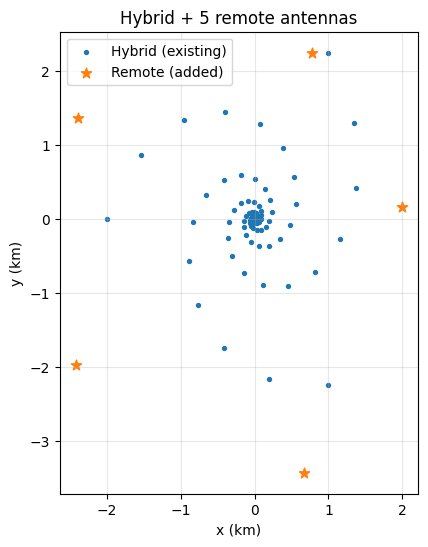

In [19]:
# Add a small number of remote antennas (3–5) at radii 6–10 km.
# Coordinates are (x, y) in meters in the same local tangent-plane system as the existing configs.

n_remote = 5  # try 3–5
rmin_m, rmax_m = 2000.0, 3500.0

# Use a deterministic seed so results are reproducible.
rng = np.random.default_rng(42)

# Spread antennas roughly uniformly in azimuth, with a small random jitter.
theta = np.linspace(0.0, 2.0 * np.pi, n_remote, endpoint=False) + rng.uniform(-0.15, 0.15, n_remote)
r_remote_m = np.linspace(rmin_m, rmax_m, n_remote)
remote_xy = np.column_stack([r_remote_m * np.cos(theta), r_remote_m * np.sin(theta)])

positions_hybrid_remote = np.vstack([positions_hybrid, remote_xy])

print("Original antennas:", len(positions_hybrid))
print("With remote antennas:", len(positions_hybrid_remote))

# Quick visualization: core/spiral points vs remote points.
plt.figure(figsize=(6, 6))
plt.scatter(positions_hybrid[:, 0] / 1000, positions_hybrid[:, 1] / 1000, s=8, label="Hybrid (existing)")
plt.scatter(remote_xy[:, 0] / 1000, remote_xy[:, 1] / 1000, s=60, marker="*", label="Remote (added)")
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x (km)")
plt.ylabel("y (km)")
plt.title(f"Hybrid + {n_remote} remote antennas")
plt.grid(True, alpha=0.3)
plt.legend()


Max baseline (hybrid): 4.49 km
Max baseline (hybrid + remote): 5.69 km
 1 GHz: ~ 13.76" (hybrid)  ->  ~ 10.86" (hybrid+remote)
 3 GHz: ~  4.59" (hybrid)  ->  ~  3.62" (hybrid+remote)
 5 GHz: ~  2.75" (hybrid)  ->  ~  2.17" (hybrid+remote)
10 GHz: ~  1.38" (hybrid)  ->  ~  1.09" (hybrid+remote)


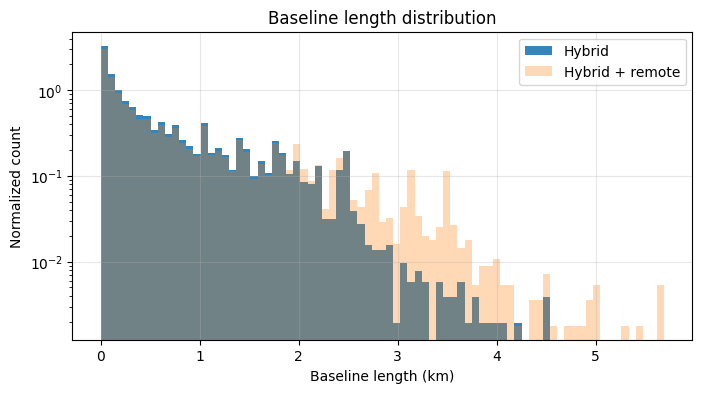

In [20]:
# Compare baseline length distributions and approximate resolution impact.
from scipy.spatial.distance import pdist

bl_hybrid_m = pdist(positions_hybrid)
bl_remote_m = pdist(positions_hybrid_remote)

print(f"Max baseline (hybrid): {bl_hybrid_m.max() / 1e3:.2f} km")
print(f"Max baseline (hybrid + remote): {bl_remote_m.max() / 1e3:.2f} km")

# Convert max baseline to an approximate diffraction-limited angular resolution.
# (This is a back-of-envelope estimate; the full PSF/beam depends on weighting and uv-coverage.)
for f_ghz in [1, 3, 5, 10]:
    res_h = fss.get_max_resolution(f_ghz, bl_hybrid_m.max())
    res_r = fss.get_max_resolution(f_ghz, bl_remote_m.max())
    print(f"{f_ghz:>2} GHz: ~{res_h:6.2f}\" (hybrid)  ->  ~{res_r:6.2f}\" (hybrid+remote)")

# Plot baseline length histograms (km).
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(1, 1, 1)
bins = np.linspace(0, bl_remote_m.max() / 1e3, 80)
ax.hist(bl_hybrid_m / 1e3, bins=bins, alpha=0.9, label="Hybrid", density=True)
ax.hist(bl_remote_m / 1e3, bins=bins, alpha=0.3, label="Hybrid + remote", density=True)
ax.set_yscale('log')
ax.set_xlabel("Baseline length (km)")
ax.set_ylabel("Normalized count")
ax.set_title("Baseline length distribution")
ax.grid(True, alpha=0.3)
ax.legend()

### Write a new CASA config and compare PSF/beam panels

This writes a new `*.cfg` including the remote antennas, then runs the same `plot_all_panels()` comparison used above.

Tip: try `frequency=10` to make the long-baseline effect easier to see.


Writing: fasr-a_random_spiral_hybrid_120_remote20_r2-3km.cfg
Wrote fasr-a_random_spiral_hybrid_120_remote20_r2-3km.cfg
Set 1: Beam (Natural) FWHM Major: 47.62 arcsec, Minor: 47.04"
Set 1: Beam (Uniform) FWHM Major: 4.68 arcsec, Minor: 4.81"
Set 1: Sidelobe RMS (Natural): 3.3%
Set 1: Sidelobe RMS (Uniform): 1.5%
Set 2: Beam (Natural) FWHM Major: 31.81 arcsec, Minor: 37.70"
Set 2: Beam (Uniform) FWHM Major: 1.89 arcsec, Minor: 2.33"
Set 2: Sidelobe RMS (Natural): 2.0%
Set 2: Sidelobe RMS (Uniform): 1.2%
'plot_all_panels' completed at 2026-02-02 14:10:03; runtime: 1.48 seconds


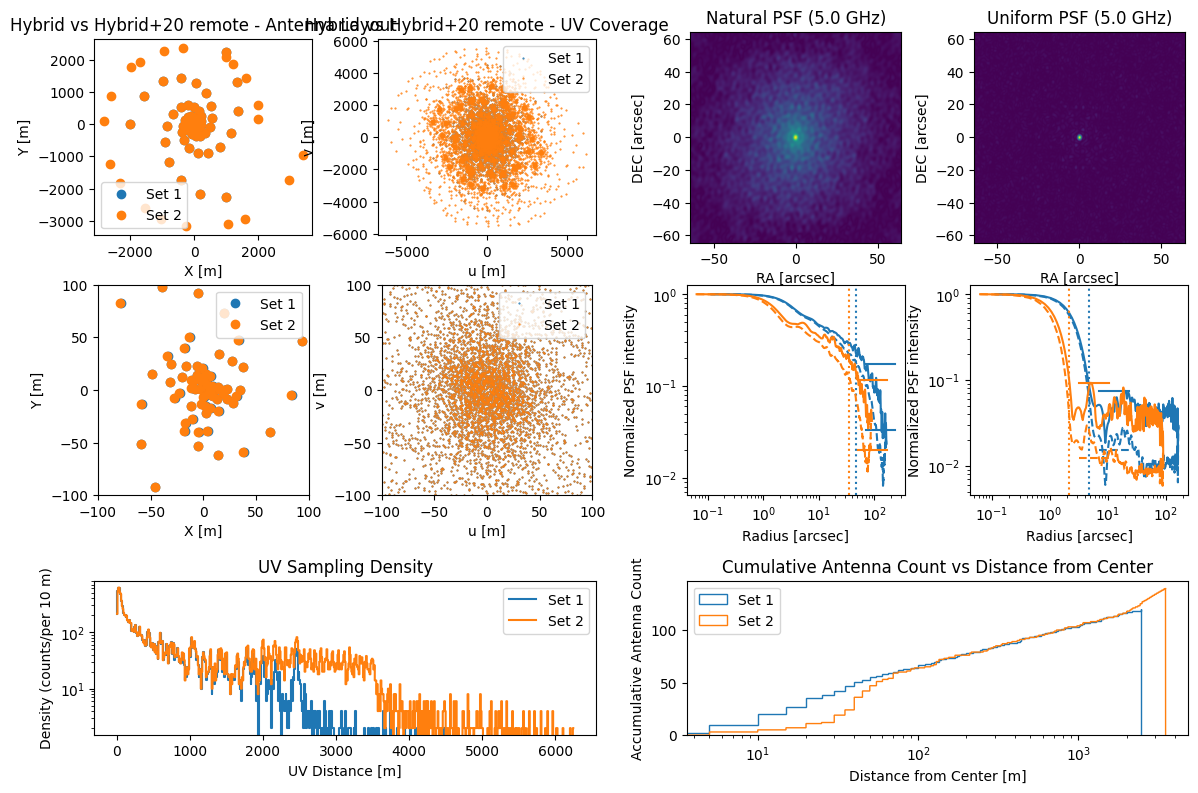

In [16]:
# Write an augmented config file (avoid overwriting existing files).
remote_tag = f"remote{n_remote}_r{int(rmin_m/1000)}-{int(rmax_m/1000)}km"
cfg_base = f"fasr-a_random_spiral_hybrid_{len(positions_hybrid)}_{remote_tag}.cfg"

cfg_out = cfg_base
if os.path.exists(cfg_out):
    n = 1
    while True:
        candidate = cfg_base.replace(".cfg", f".{n:03d}.cfg")
        if not os.path.exists(candidate):
            cfg_out = candidate
            break
        n += 1

print("Writing:", cfg_out)
fss.write_casa_antenna_list(
    cfg_out,
    positions_hybrid_remote,
    cofa_lon=dsa_longitude,
    cofa_lat=dsa_latitude,
    cofa_alt=dsa_altitude,
    diam=1.5,
)

# Read back and compare PSF/beam panels.
positions_aug, _ = fss.read_casa_antenna_list(cfg_out)
fss.plot_all_panels(
    [positions_hybrid, positions_aug],
    f"Hybrid vs Hybrid+{n_remote} remote",
    frequency=5,
    plot_psf_fit=False,
    no_psf_legend=True,
)
